In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

menu = pd.read_csv("C:/Users/LENOVO/OneDrive/Desktop/Restaurant_Orders/menu_items.csv")
orders = pd.read_csv("C:/Users/LENOVO/OneDrive/Desktop/Restaurant_Orders/order_details.csv")

In [4]:
menu.head()
orders.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,01-01-23,11:38:36 AM,109.0
1,2,2,01-01-23,11:57:40 AM,108.0
2,3,2,01-01-23,11:57:40 AM,124.0
3,4,2,01-01-23,11:57:40 AM,117.0
4,5,2,01-01-23,11:57:40 AM,129.0


In [5]:
print(menu.shape)
print(orders.shape)

(32, 4)
(12234, 5)


In [6]:
menu.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   menu_item_id  32 non-null     int64  
 1   item_name     32 non-null     object 
 2   category      32 non-null     object 
 3   price         32 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12234 non-null  int64  
 1   order_id          12234 non-null  int64  
 2   order_date        12234 non-null  object 
 3   order_time        12234 non-null  object 
 4   item_id           12097 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 478.0+ KB


In [7]:
orders[orders["item_id"].isnull()]

,order_details_id,order_id,order_date,order_time,item_id
121,122,50,01-01-23,6:41:01 PM,NaN
297,298,125,01-02-23,8:31:06 PM,NaN
357,358,147,01-03-23,2:32:51 PM,NaN
386,387,161,01-03-23,4:43:46 PM,NaN
469,470,200,01-03-23,10:24:05 PM,NaN
...,...,...,...,...,...
11716,11717,5149,3/28/23,2:48:50 PM,NaN
11903,11904,5225,3/29/23,5:40:52 PM,NaN
11906,11907,5226,3/29/23,5:43:56 PM,NaN
12021,12022,5281,3/30/23,4:56:04 PM,NaN


In [12]:
orders = orders.dropna(subset=["item_id"])

In [10]:
orders["item_id"] = orders["item_id"].astype(int)

In [18]:
orders["order_time"] = pd.to_datetime(
    orders["order_time"],
    format="%I:%M:%S %p"
).dt.time

In [19]:
orders["order_time"].head()

0    11:38:36
1    11:57:40
2    11:57:40
3    11:57:40
4    11:57:40
Name: order_time, dtype: object

In [20]:
df = orders.merge(menu, left_on="item_id", right_on="menu_item_id", how="left")

In [21]:
df.isnull().sum()

order_details_id    0
order_id            0
order_date          0
order_time          0
item_id             0
order_datetime      0
menu_item_id        0
item_name           0
category            0
price               0
dtype: int64

In [22]:
invalid_ids = set(orders["item_id"]) - set(menu["menu_item_id"])
invalid_ids

set()

# What are the Top 5 Most Ordered Items?

In [23]:
top_items = df.groupby("item_name")["order_id"].count().sort_values(ascending=False).head(5)

top_items

item_name
Hamburger           622
Edamame             620
Korean Beef Bowl    588
Cheeseburger        583
French Fries        571
Name: order_id, dtype: int64

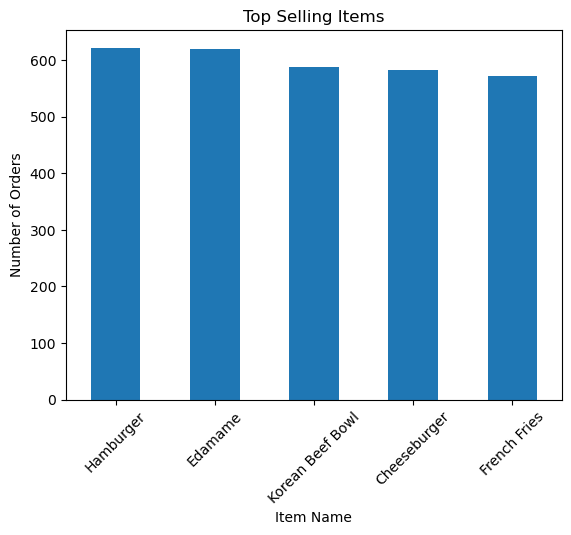

In [26]:
import matplotlib.pyplot as plt

# Plot
top_items.plot(kind="bar")

# Titles and labels
plt.title("Top Selling Items")
plt.xlabel("Item Name")
plt.ylabel("Number of Orders")

# Rotate x labels for readability
plt.xticks(rotation=45)

# Show plot
plt.show()

In [ ]:
# Hamburgers, Edamame, and Korean Beef Bowl are the top-selling items, showing that customers prefer classic fast-food and quick meals.

# What is the Total Revenue Generated?

In [27]:
df["total_revenue"] = df["price"]

total_revenue = df["total_revenue"].sum()

total_revenue

np.float64(159217.9)

In [ ]:
# The business generated a total revenue of 159,217.9, indicating strong overall sales performance.

# Revenue by Category

In [28]:
revenue_by_category = df.groupby("category")["price"].sum().sort_values(ascending=False)

revenue_by_category

category
Italian     49462.70
Asian       46720.65
Mexican     34796.80
American    28237.75
Name: price, dtype: float64

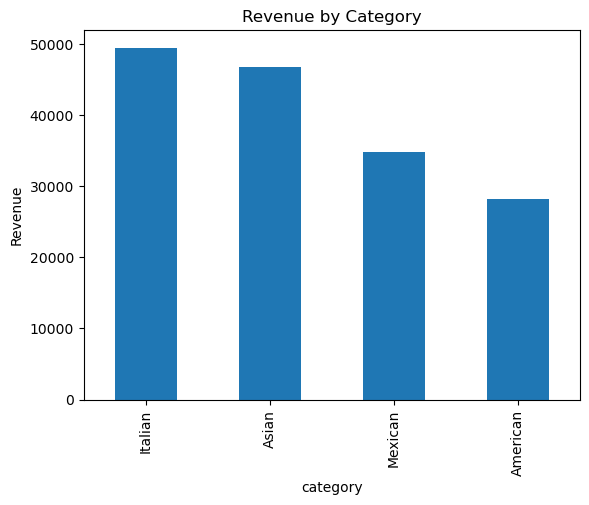

In [29]:
import matplotlib.pyplot as plt

revenue_by_category.plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# Italian and Asian dishes generate the highest revenue, followed by Mexican and American, showing a clear preference for Italian and Asian cuisine.

# What Are the Peak Ordering Hours?

In [32]:
df["hour"] = df["order_datetime"].dt.hour

hourly_orders = df.groupby("hour")["order_id"].count()

hourly_orders

hour
10       5
11     624
12    1659
13    1558
14     956
15     743
16    1035
17    1355
18    1290
19    1074
20     882
21     600
22     305
23      11
Name: order_id, dtype: int64

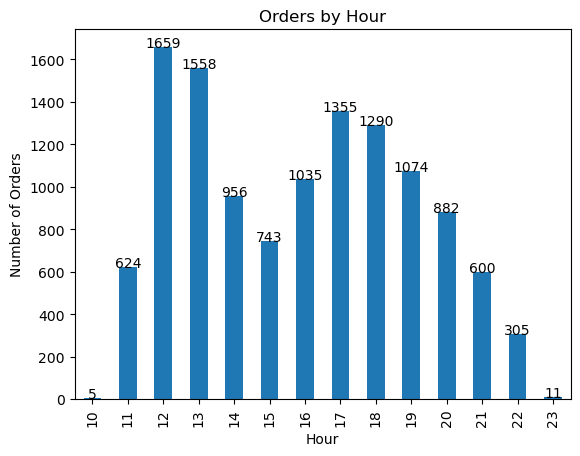

In [53]:
plt.figure()
hourly_orders.plot(kind="bar")

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

for i, value in enumerate(hourly_orders):
    plt.text(i, value, str(value), ha='center')

plt.show()

In [ ]:
# Most orders occur between 12 PM and 1 PM, indicating lunchtime is the busiest period, with a smaller peak around 5–6 PM for dinner orders.

# What is the Average Order Value Per Day?

In [34]:
order_revenue = df.groupby("order_id")["total_revenue"].sum()

In [37]:
df["order_date"] = df["order_datetime"].dt.date

daily_avg_order_value = df.groupby("order_date")["total_revenue"].sum() / df.groupby("order_date")["order_id"].nunique()

daily_avg_order_value.head()

order_date
2023-01-01    30.758824
2023-01-02    30.222727
2023-01-03    30.995313
2023-01-04    26.093269
2023-01-05    29.441667
dtype: float64

In [ ]:
# The average order value stays around 30, with slight daily fluctuations, indicating consistent spending per transaction.